This cell imports all necessary libraries for the project, including tools for file/utility operations, data handling (NumPy, Pandas), visualization (Matplotlib, Seaborn), deep learning with PyTorch and timm, and machine learning/evaluation utilities from scikit-learn. It also includes tqdm for progress tracking and kagglehub/Path for downloading and managing Kaggle datasets, then prints a confirmation message.

In [ ]:
import os
import shutil
import random
import itertools
import time
import platform
import re


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
import timm

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from scipy.special import softmax
from sklearn.manifold import TSNE

from tqdm import tqdm

import kagglehub
from pathlib import Path

print("All libraries imported successfully.")


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

All libraries imported successfully.


This block imports core utilities for file handling, timing, copying objects, JSON/CSV processing, randomness, system checks, and resource monitoring (psutil), along with libraries for data analysis and visualization (NumPy, Pandas, Matplotlib, Seaborn). It also brings in image-processing tools (OpenCV and PIL) and the main PyTorch/torchvision components needed to build models, apply transforms, and load data efficiently using Dataset and DataLoader.

In [2]:
import os
import time
import copy
import json
import random
import platform
import csv
import psutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import PIL
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader



This section checks the current Kaggle runtime environment.
It collects and displays:
CPU model using the platform library
Total RAM (in GB) using psutil
GPU name via the nvidia-smi command (if a GPU is available)

In [3]:
import psutil

cpu_info = platform.processor()
ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    gpu_name = gpu_info[1]
except:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)

CPU: x86_64
Total RAM (GB): 31.35
GPU: Tesla P100-PCIE-16GB


This code organizes PM25Vision images by air-quality labels.
It reads metadata.csv, maps PM2.5 bins to categories (Good, Moderate, Unhealthy, etc.), creates label folders, and copies images accordingly.
Finally, it prints summary counts and skipped files — readying the dataset for training.

In [4]:
import re
import shutil
import pandas as pd
from pathlib import Path


CSV_PATH = Path("/kaggle/input/pm25vision/train/metadata.csv")
IMG_DIR  = Path("/kaggle/input/pm25vision/train/images")
OUT_DIR  = Path("/kaggle/working/dataset")
OUT_DIR.mkdir(parents=True, exist_ok=True)


AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None  

def bin_to_label(bin_val) -> str:
    """
    Accepts '0–50', '0-50', '0 — 50', etc.
    Extracts the LOWER numeric bound and maps to label.
    """
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None
    lo = int(m.group(1))
    return aqi_to_label(lo)


df = pd.read_csv(CSV_PATH)
assert "pm25_bin" in df.columns, f"Expected 'pm25_bin' column but found {df.columns}"

fname_col = "filename" if "filename" in df.columns else ("file" if "file" in df.columns else None)
if fname_col is None:
    raise ValueError(f"No image filename column found. Columns: {list(df.columns)}")

df["fname"] = df[fname_col].astype(str)
df["level"] = df["pm25_bin"].apply(bin_to_label)


df = df.dropna(subset=["level"])

print("Class counts:")
print(df["level"].value_counts(dropna=False))


for _, _, label in AQI_BINS:
    (OUT_DIR / label).mkdir(parents=True, exist_ok=True)

missing = 0
copied  = 0
valid_labels = {b[2] for b in AQI_BINS}

for _, row in df.iterrows():
    src = IMG_DIR / row["fname"]
    if not src.exists():
        missing += 1
        continue

    if row["level"] not in valid_labels:
        continue

    dst = OUT_DIR / row["level"] / src.name
    shutil.copy2(src, dst)
    copied += 1

print(f"✅ Done! Copied: {copied} | Missing files skipped: {missing}")
print(f"Output root: {OUT_DIR}")


Class counts:
level
Good                   1780
Moderate               1780
Unhealthy_Sensitive    1780
Unhealthy              1780
Very_Unhealthy          822
Hazardous               356
Name: count, dtype: int64
✅ Done! Copied: 8298 | Missing files skipped: 0
Output root: /kaggle/working/dataset


This block organizes the test images into the same labeled structure as the training dataset.
It reads metadata.csv, maps PM2.5 bins to air-quality categories, and copies each image into its respective label folder under /kaggle/working/dataset/.
Duplicate files are checked and renamed if needed, while missing images are skipped.
Finally, it prints a summary of copied, skipped, and renamed files.

In [5]:
TEST_CSV_PATH = Path("/kaggle/input/pm25vision/test/metadata.csv")
TEST_IMG_DIR  = Path("/kaggle/input/pm25vision/test/images")
OUT_DIR       = Path("/kaggle/working/dataset") 


AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str | None:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None 

def bin_to_label(bin_val) -> str | None:
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None  
    lo = int(m.group(1))
    return aqi_to_label(lo)


df_t = pd.read_csv(TEST_CSV_PATH)
assert "pm25_bin" in df_t.columns, f"Expected 'pm25_bin' in TEST CSV, got: {df_t.columns}"

fname_col_t = "filename" if "filename" in df_t.columns else ("file" if "file" in df_t.columns else None)
if fname_col_t is None:
    raise ValueError(f"No image filename column in TEST CSV. Columns: {list(df_t.columns)}")

df_t["fname"] = df_t[fname_col_t].astype(str)
df_t["level"] = df_t["pm25_bin"].apply(bin_to_label)

missing, copied, skipped_same, renamed_dupe = 0, 0, 0, 0
valid_labels = {b[2] for b in AQI_BINS}

for _, r in df_t.iterrows():
    src = TEST_IMG_DIR / r["fname"]
    if not src.exists():
        missing += 1
        continue

 
    if r["level"] not in valid_labels:
        continue

    dest_dir = OUT_DIR / r["level"]
    dest_dir.mkdir(parents=True, exist_ok=True)

    dst = dest_dir / src.name
    if dst.exists():
     
        if os.path.getsize(dst) == os.path.getsize(src):
            skipped_same += 1
            continue
        dst = dest_dir / f"test__{src.name}"
        renamed_dupe += 1

    shutil.copy2(src, dst)
    copied += 1

print("✅ TEST merge complete.")
print(f"Copied: {copied} | Missing files: {missing} | Skipped exact-duplicates: {skipped_same} | Renamed (name clash): {renamed_dupe}")
print(f"Merged into: {OUT_DIR}")


✅ TEST merge complete.
Copied: 2905 | Missing files: 0 | Skipped exact-duplicates: 16 | Renamed (name clash): 0
Merged into: /kaggle/working/dataset


This code counts the number of images in each air-quality class under /kaggle/working/dataset/.
It prints per-class image totals and the overall dataset size — useful for confirming that all files were organized correctly.

In [6]:
from pathlib import Path
import shutil

OUT_DIR = Path("/kaggle/working/dataset")


unknown_dir = OUT_DIR / "Unknown"
if unknown_dir.exists() and unknown_dir.is_dir():
    shutil.rmtree(unknown_dir)


class_counts = {}
for sub in OUT_DIR.iterdir():
    if sub.is_dir():
        class_counts[sub.name] = len(list(sub.glob("*")))

print(" Image count per class:\n")

for k, v in sorted(class_counts.items()):
    print(f"{k:20s}: {v}")

print("\nTotal images:", sum(class_counts.values()))

 Image count per class:

Good                : 2408
Hazardous           : 481
Moderate            : 2407
Unhealthy           : 2407
Unhealthy_Sensitive : 2393
Very_Unhealthy      : 1007

Total images: 11103


This code scans the organized dataset under /kaggle/working/dataset/ and builds a DataFrame listing each image path and its label.
It filters valid image formats (.jpg, .jpeg, .png), counts total samples per class, and defines a helper function to load images as RGB arrays.
Useful for quick checks, visualization, or later data-loader creation.

In [7]:
from pathlib import Path
from PIL import Image

BASE_DIR = Path("/kaggle/working/dataset")  
assert BASE_DIR.exists(), BASE_DIR

rows = []
for label_dir in sorted([p for p in BASE_DIR.iterdir() if p.is_dir()]):
    label = label_dir.name
    for p in label_dir.glob("*"):
        if p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(p), "label": label})

df = pd.DataFrame(rows)
print("Total images indexed:", len(df))
print("Class balance:\n", df["label"].value_counts())

def load_rgb(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        return np.array(im)

df.head(20)

Total images indexed: 11103
Class balance:
 label
Good                   2408
Moderate               2407
Unhealthy              2407
Unhealthy_Sensitive    2393
Very_Unhealthy         1007
Hazardous               481
Name: count, dtype: int64


,path,label
0,/kaggle/working/dataset/Good/516868262663360.jpg,Good
1,/kaggle/working/dataset/Good/500667141358146.jpg,Good
2,/kaggle/working/dataset/Good/719724466330436.jpg,Good
3,/kaggle/working/dataset/Good/1440425266865574.jpg,Good
4,/kaggle/working/dataset/Good/323688092593766.jpg,Good
5,/kaggle/working/dataset/Good/800946248686410.jpg,Good
6,/kaggle/working/dataset/Good/432544562485734.jpg,Good
7,/kaggle/working/dataset/Good/159738662647458.jpg,Good
8,/kaggle/working/dataset/Good/1842115966120667.jpg,Good
9,/kaggle/working/dataset/Good/1959412187549273.jpg,Good


This code visualizes the number of images in each air-quality category using a Seaborn bar chart.
It helps verify dataset balance and ensure all classes are properly represented before training.

Ephoch Number Declaration

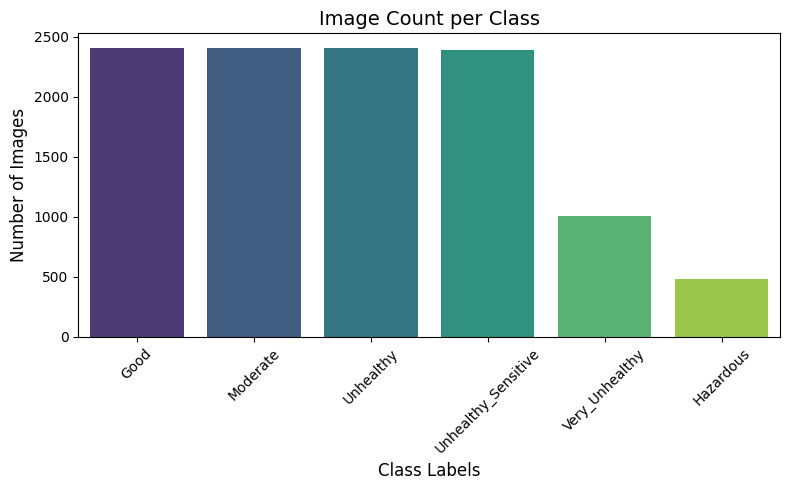

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df["label"].value_counts().index,
            y=df["label"].value_counts().values,
            palette="viridis")
plt.title("Image Count per Class", fontsize=14)
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This code displays a small gallery showing two random sample images from each air-quality class.
It helps visually verify the dataset and observe differences across categories such as Good, Moderate, and Unhealthy.
Useful for quick quality checks and understanding visual variation before model training.

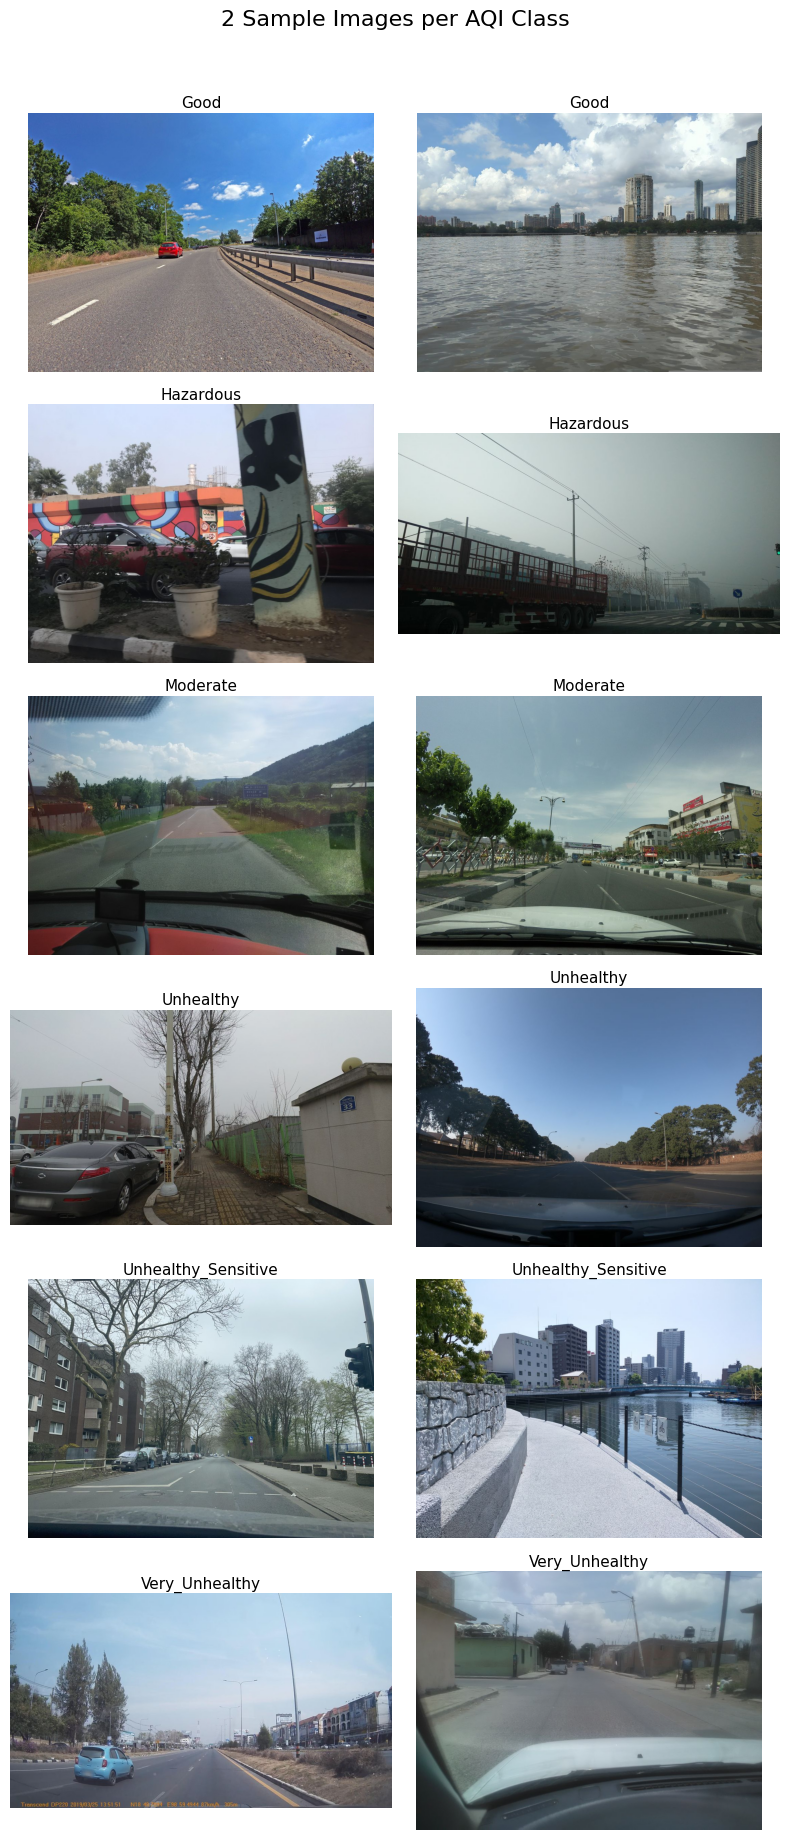

In [9]:
from PIL import Image

classes = sorted(df["label"].unique())

N_PER_CLASS = 2

plt.figure(figsize=(N_PER_CLASS * 4, len(classes) * 3))

for i, lbl in enumerate(classes):
    subset = df[df["label"] == lbl]["path"].tolist()
    sample_paths = random.sample(subset, min(N_PER_CLASS, len(subset)))
    
    for j, path in enumerate(sample_paths):
        idx = i * N_PER_CLASS + j + 1
        plt.subplot(len(classes), N_PER_CLASS, idx)
        
        img = Image.open(path)
        plt.imshow(img)
        plt.axis("off")
        
        plt.title(lbl, fontsize=11, pad=4)

plt.suptitle("2 Sample Images per AQI Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

This block divides the dataset into train, validation, and test sets for multiple ratios (from 90:10 down to 10:90).
Each split is stratified by class labels to keep class balance and uses a fixed random seed (42) for reproducibility.
From the training portion, 10% is further used as validation.
All splits are saved in dictionaries (SPLITS, FIXED_IDX) and a summary table shows image counts for every ratio

In [ ]:
original_base_dir = "/kaggle/working/dataset"
new_base_dir = "/kaggle/working/final_data"

data = []
for label in os.listdir(original_base_dir):
    path = os.path.join(original_base_dir, label)
    if not os.path.isdir(path):
        continue
    for fname in os.listdir(path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG')):
            data.append({'path': os.path.join(path, fname), 'label': label})

df = pd.DataFrame(data)

train_val, test = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)
train, val = train_test_split(train_val, test_size=0.1, stratify=train_val['label'], random_state=42)

print(f"Total images: {len(df)}")
print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

for split_df, split in zip([train, val, test], ['train', 'val', 'test']):
    for _, row in split_df.iterrows():
        dst_dir = os.path.join(new_base_dir, split, row['label'])
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy(row['path'], os.path.join(dst_dir, os.path.basename(row['path'])))


Total images: 11103
Train: 8992, Val: 1000, Test: 1111


This code sets a fixed random seed (42) for PyTorch (CPU and CUDA), NumPy, and Python’s random module to make training and other randomized operations more reproducible across runs.

In [11]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)


This section defines a custom PyTorch Dataset (ImageDataset) that loads images from file paths, converts them to RGB, applies optional preprocessing/augmentation transforms, and returns each image with its label. It also provides a helper function get_dinov2_transforms() to create DINOv2-style transforms: heavier augmentations for training (flip, rotation, color jitter) and a simpler resize + normalization pipeline for evaluation.

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class ImageDataset(Dataset):
    """Custom dataset for image classification"""
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


def get_dinov2_transforms(is_training=False, img_size=224):

    if is_training:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])


This block builds a DINOv2-based image classification model using a pretrained Vision Transformer from timm. First, DINOv2FeatureExtractor loads the pretrained DINOv2 ViT backbone, optionally freezes its weights to prevent fine-tuning, and outputs feature embeddings. Then, DINOv2Classifier wraps that backbone with a lightweight classification head (LayerNorm → Dropout → Linear) to produce class logits, and also provides a get_features() method to extract embeddings without running the classifier.

In [ ]:
class DINOv2FeatureExtractor(nn.Module):

    def __init__(self, model_name='vit_base_patch14_dinov2.lvd142m', pretrained=True, freeze_backbone=True):
        super().__init__()

        # Load pretrained DINOv2 model
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)

        # Freeze backbone if specified
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Get feature dimension
        self.feature_dim = self.backbone.num_features

    def forward(self, x):
        return self.backbone(x)


class DINOv2Classifier(nn.Module):
    def __init__(self, num_classes, model_name='vit_base_patch14_dinov2.lvd142m',
                 pretrained=True, freeze_backbone=True, dropout=0.1):
        super().__init__()

        self.feature_extractor = DINOv2FeatureExtractor(
            model_name=model_name,
            pretrained=pretrained,
            freeze_backbone=freeze_backbone
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.feature_extractor.feature_dim),
            nn.Dropout(dropout),
            nn.Linear(self.feature_extractor.feature_dim, num_classes)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        logits = self.classifier(features)
        return logits

    def get_features(self, x):
        return self.feature_extractor(x)


This section defines a create_model() helper that builds a DINOv2-based classifier using different ViT backbone sizes (small/base/large/giant) and optionally freezes the backbone for feature-extraction training. The example __main__ block then sets basic training settings (batch size, image size, device), creates the model, moves it to GPU/CPU, runs a quick forward pass on a dummy image to verify output and feature shapes, and prints total vs trainable (unfrozen) parameter counts to confirm freezing worked.

In [ ]:
def create_model(num_classes, freeze_backbone=True, model_variant='base'):
    
    model_names = {
        'small': 'vit_small_patch14_dinov2.lvd142m',
        'base': 'vit_base_patch14_dinov2.lvd142m',
        'large': 'vit_large_patch14_dinov2.lvd142m',
        'giant': 'vit_giant_patch14_dinov2.lvd142m'
    }

    model_name = model_names.get(model_variant, model_names['base'])

    model = DINOv2Classifier(
        num_classes=num_classes,
        model_name=model_name,
        pretrained=True,
        freeze_backbone=freeze_backbone,
        dropout=0.1
    )
    return model


if __name__ == "__main__":
    BATCH_SIZE = 32
    IMG_SIZE = 518
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    _num_classes_placeholder = 10

    model = create_model(
        num_classes=_num_classes_placeholder,
        freeze_backbone=True,
        model_variant='base'
    )
    model = model.to(DEVICE)

    print("Model created successfully!")
    print(f"Feature dimension: {model.feature_extractor.feature_dim}")
    print(f"Number of classes: {_num_classes_placeholder}")

    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    with torch.no_grad():
        output = model(dummy_input)
        features = model.get_features(dummy_input)

    print(f"Output shape: {output.shape}")
    print(f"Features shape: {features.shape}")

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Frozen parameters: {total_params - trainable_params:,}")


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model created successfully!
Feature dimension: 768
Number of classes: 10
Output shape: torch.Size([1, 10])
Features shape: torch.Size([1, 768])
Total parameters: 86,588,938
Trainable parameters: 9,226
Frozen parameters: 86,579,712


This block initializes key global settings by reading the training folder to detect class names, computing NUM_CLASSES, and creating class-to-index/index-to-class mappings for label encoding. It also selects the runtime device (GPU if available), instantiates a frozen-backbone DINOv2 “base” model on that device, and sets common training constants like batch size and image size.

In [ ]:
base_folder = "/kaggle/working/final_data/train"
all_class_dirs = sorted(os.listdir(base_folder))

NUM_CLASSES = len(all_class_dirs)
print(f"Global NUM_CLASSES set to: {NUM_CLASSES}")

class_to_idx = {class_name: i for i, class_name in enumerate(all_class_dirs)}
idx_to_class = {i: class_name for class_name, i in class_to_idx.items()}

print("Class mapping:", class_to_idx)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)

m_model = create_model(
    num_classes=NUM_CLASSES,
    freeze_backbone=True,
    model_variant='base'
).to(DEVICE)

print("Global DINOv2 model instantiated.")
BATCH_SIZE = 32
IMG_SIZE = 518


Global NUM_CLASSES set to: 6
Class mapping: {'Good': 0, 'Hazardous': 1, 'Moderate': 2, 'Unhealthy': 3, 'Unhealthy_Sensitive': 4, 'Very_Unhealthy': 5}
Using device: cuda
Global DINOv2 model instantiated.


This block builds the train/validation/test pipelines by scanning each split directory, collecting image file paths and their class labels into Pandas DataFrames, and converting the string labels into integer IDs using class_to_idx. It then applies DINOv2-style transforms (augmented for training, standard for validation/testing), wraps the data in the custom ImageDataset, and finally creates PyTorch DataLoaders with the chosen batch size and shuffling settings, confirming that all loaders are ready.

In [ ]:
train_dir = "/kaggle/working/final_data/train"
val_dir = "/kaggle/working/final_data/val"
test_dir = "/kaggle/working/final_data/test"

train_df = []
for label in os.listdir(train_dir):
    for f in os.listdir(os.path.join(train_dir, label)):
        train_df.append({"path": os.path.join(train_dir, label, f), "label": label})
train_df = pd.DataFrame(train_df)

val_df = []
for label in os.listdir(val_dir):
    for f in os.listdir(os.path.join(val_dir, label)):
        val_df.append({"path": os.path.join(val_dir, label, f), "label": label})
val_df = pd.DataFrame(val_df)

test_df = []
for label in os.listdir(test_dir):
    for f in os.listdir(os.path.join(test_dir, label)):
        test_df.append({"path": os.path.join(test_dir, label, f), "label": label})
test_df = pd.DataFrame(test_df)

def prepare_data_lists(dataframe, class_to_idx):
    return dataframe["path"].tolist(), [class_to_idx[x] for x in dataframe["label"]]

train_image_paths, train_labels_int = prepare_data_lists(train_df, class_to_idx)
val_image_paths, val_labels_int = prepare_data_lists(val_df, class_to_idx)
test_image_paths, test_labels_int = prepare_data_lists(test_df, class_to_idx)

train_transform = get_dinov2_transforms(is_training=True, img_size=IMG_SIZE)
val_transform = get_dinov2_transforms(is_training=False, img_size=IMG_SIZE)

train_dataset = ImageDataset(train_image_paths, train_labels_int, train_transform)
val_dataset = ImageDataset(val_image_paths, val_labels_int, val_transform)
test_dataset = ImageDataset(test_image_paths, test_labels_int, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train, Val, Test loaders ready.")


Train, Val, Test loaders ready.


This block creates a full embedding-visualization pipeline for your DINOv2 model. It first defines extract_embeddings() (run in inference mode with @torch.no_grad()) to loop through a DataLoader and collect either the classifier head outputs (logits) or the backbone feature vectors into NumPy arrays. Then it defines visualize_tsne() to reduce those embeddings to 2D using t-SNE and plot them with colors per class (optionally showing class names on the colorbar and saving the figure). Finally, run_tsne_analysis() runs the whole process twice—once for logits and once for backbone features—generating and saving both t-SNE plots, and the __main__ example applies this to the test set and also compares multiple perplexity values by plotting several t-SNE projections side by side.


Using current DINOv2Classifier model weights.

Extracting Classification Head Output (Logits, 6-dim)


Extracting embeddings: 100%|██████████| 35/35 [00:57<00:00,  1.65s/it]


Logits embedding shape: (1111, 6)
Labels shape: (1111,)

Running t-SNE with perplexity=30...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1111 samples in 0.002s...
[t-SNE] Computed neighbors for 1111 samples in 0.041s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1111
[t-SNE] Computed conditional probabilities for sample 1111 / 1111
[t-SNE] Mean sigma: 0.388847
[t-SNE] KL divergence after 100 iterations with early exaggeration: 71.302277
[t-SNE] KL divergence after 1000 iterations: 1.514024
Saved: tsne_logits_test.png


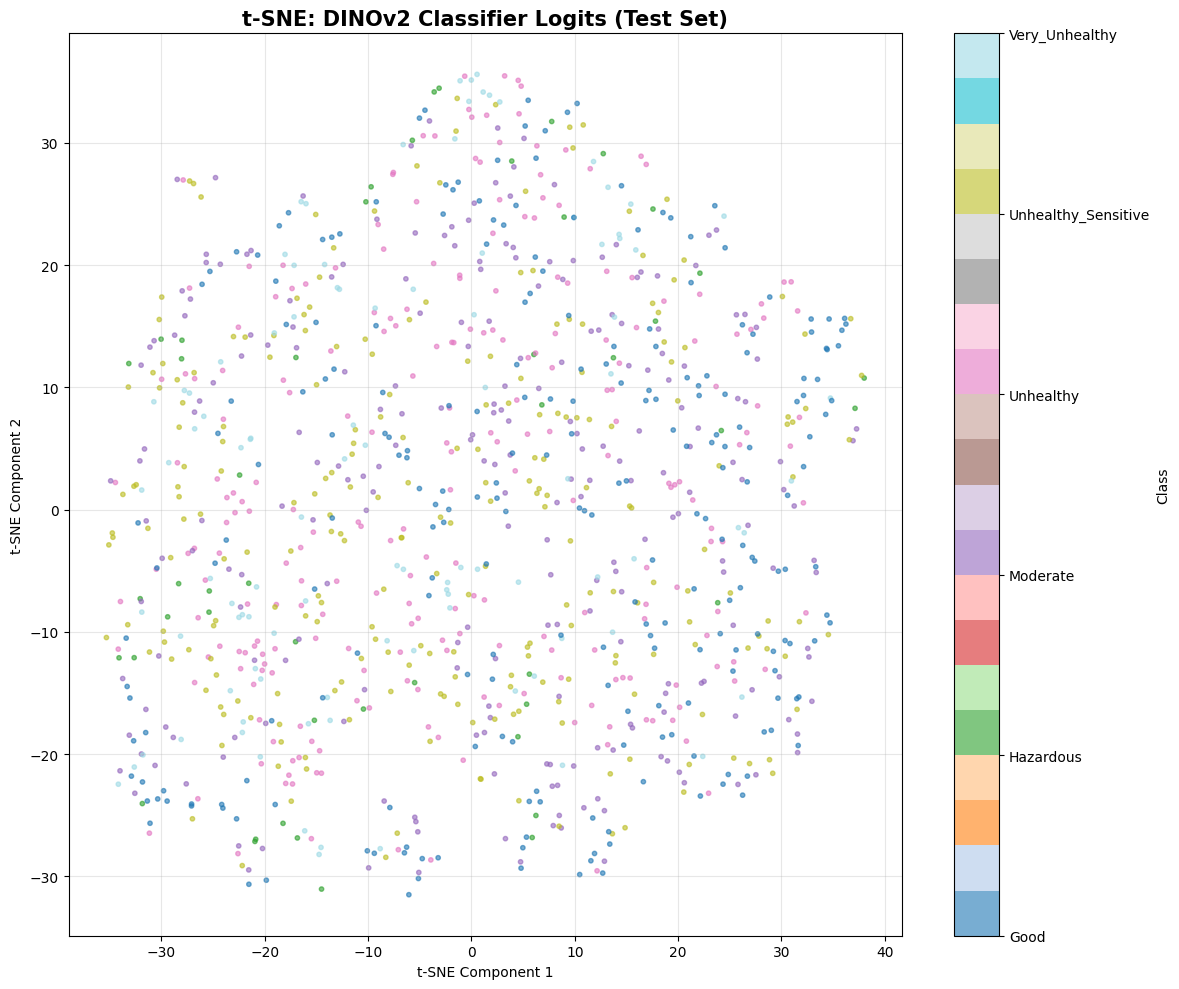


Extracting DINOv2 Backbone Features (768-dim)


Extracting embeddings: 100%|██████████| 35/35 [00:58<00:00,  1.67s/it]


Backbone embedding shape: (1111, 768)

Running t-SNE with perplexity=30...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1111 samples in 0.001s...
[t-SNE] Computed neighbors for 1111 samples in 0.202s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1111
[t-SNE] Computed conditional probabilities for sample 1111 / 1111
[t-SNE] Mean sigma: 15.786118
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.987411
[t-SNE] KL divergence after 1000 iterations: 1.023765
Saved: tsne_features_test.png


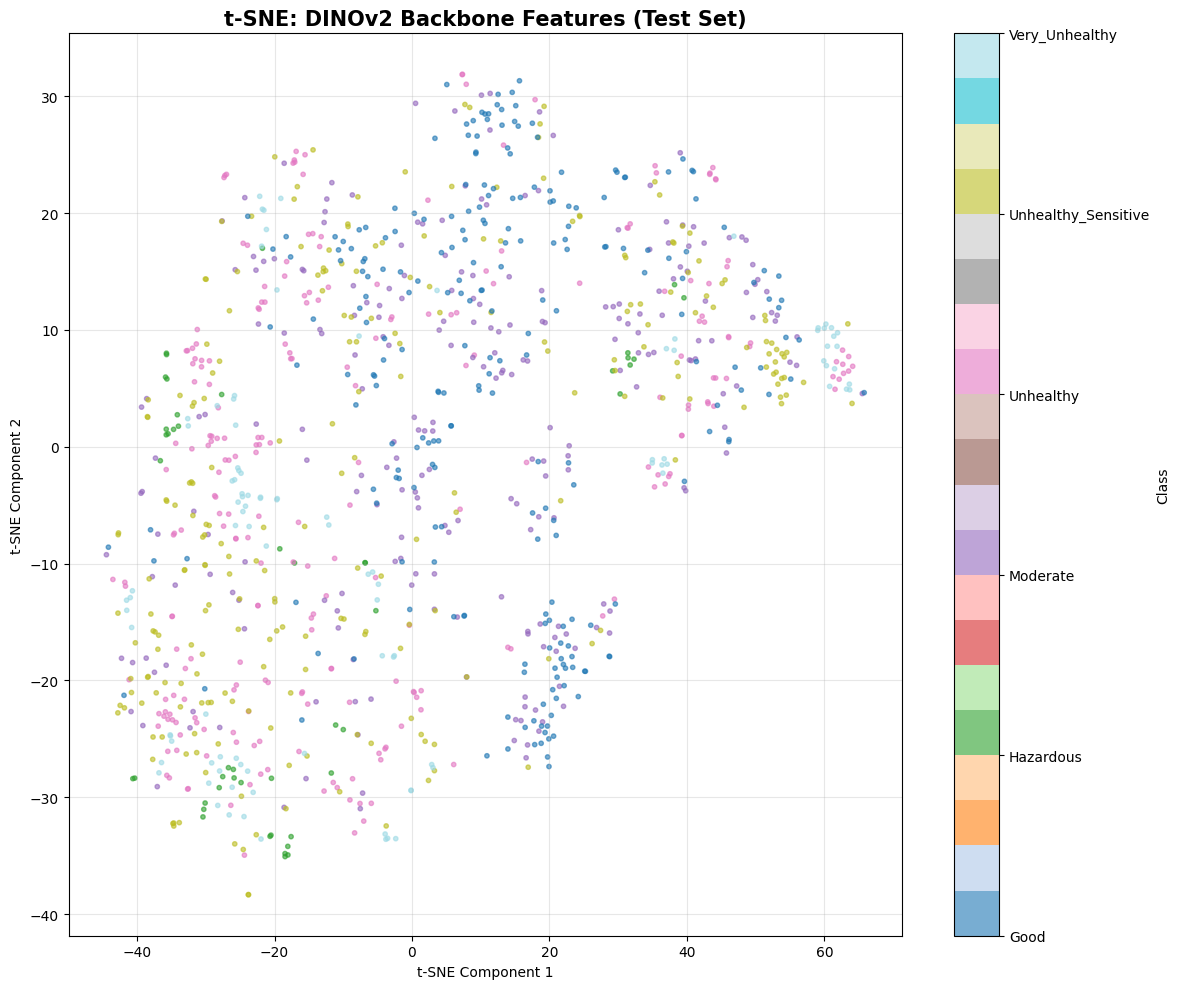


Comparing Different Perplexity Values for DINOv2 Backbone Features


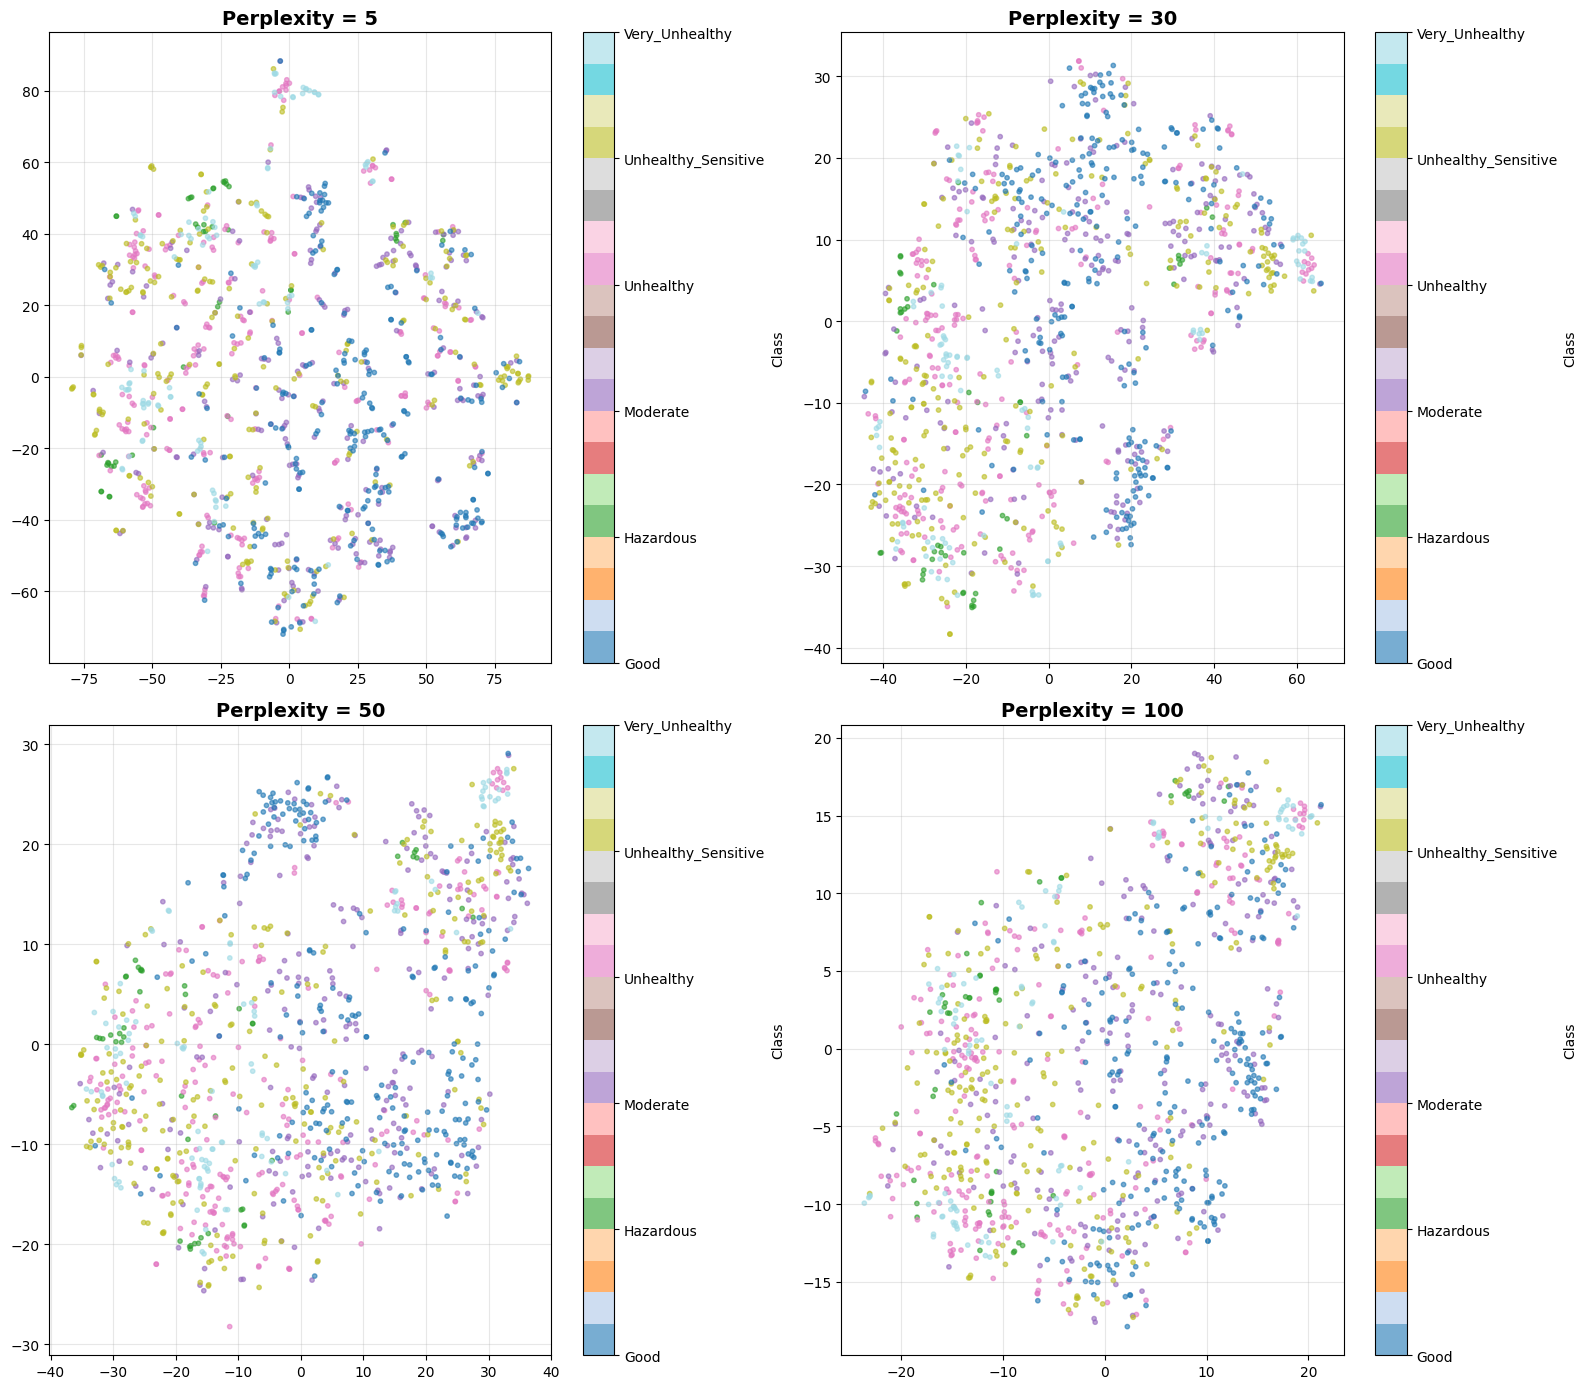


✅ t-SNE analysis complete!


In [ ]:
@torch.no_grad()
def extract_embeddings(model, loader, device, use_classifier_output=True):
    
    model.eval()
    all_embeddings = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Extracting embeddings"):
        images = images.to(device)

        if use_classifier_output:
            embeddings = model(images)
        else:
            embeddings = model.get_features(images)

        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(labels.numpy())

    embeddings = np.vstack(all_embeddings)
    labels = np.concatenate(all_labels)

    return embeddings, labels

def visualize_tsne(embeddings, labels, title="t-SNE Visualization",
                   perplexity=30, n_iter=1000, random_state=42,
                   figsize=(12, 10), save_path=None, class_names=None):
    

    print(f"\nRunning t-SNE with perplexity={perplexity}...")

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        n_iter=n_iter,
        random_state=random_state,
        verbose=1
    )
    embeddings_2d = tsne.fit_transform(embeddings)


    plt.figure(figsize=figsize)
    scatter = plt.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=labels,
        cmap='tab20',
        alpha=0.6,
        s=10
    )

    if class_names is not None:
        cbar = plt.colorbar(scatter, ticks=np.unique(labels), label='Class')
        cbar.set_ticklabels([class_names[i] for i in np.unique(labels)])
    else:
        plt.colorbar(scatter, label='Class')

    plt.title(title, fontsize=15, fontweight='bold')
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")

    plt.show()

    return embeddings_2d


def run_tsne_analysis(model, loader, device, dataset_name="Test", class_names=None):

    print("\nUsing current DINOv2Classifier model weights.")

    print("\n" + "="*60)
    print(f"Extracting Classification Head Output (Logits, {model.classifier[2].out_features}-dim)")
    print("="*60)

    logits_embeddings, labels = extract_embeddings(
        model, loader, device, use_classifier_output=True
    )

    print("Logits embedding shape:", logits_embeddings.shape)
    print("Labels shape:", labels.shape)

    visualize_tsne(
        logits_embeddings,
        labels,
        title=f"t-SNE: DINOv2 Classifier Logits ({dataset_name} Set)",
        save_path=f"tsne_logits_{dataset_name.lower()}.png",
        class_names=class_names
    )

    print("\n" + "="*60)
    print(f"Extracting DINOv2 Backbone Features ({model.feature_extractor.feature_dim}-dim)")
    print("="*60)

    feature_embeddings, labels = extract_embeddings(
        model, loader, device, use_classifier_output=False
    )

    print("Backbone embedding shape:", feature_embeddings.shape)

    visualize_tsne(
        feature_embeddings,
        labels,
        title=f"t-SNE: DINOv2 Backbone Features ({dataset_name} Set)",
        save_path=f"tsne_features_{dataset_name.lower()}.png",
        class_names=class_names
    )

    return logits_embeddings, feature_embeddings, labels


if __name__ == "__main__":

    sorted_class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    logits_emb, feature_emb, test_labels = run_tsne_analysis(
        m_model,
        test_loader,
        DEVICE,
        dataset_name="Test",
        class_names=sorted_class_names
    )

    print("\n" + "="*60)
    print("Comparing Different Perplexity Values for DINOv2 Backbone Features")
    print("="*60)

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    perplexities = [5, 30, 50, 100]

    for idx, perp in enumerate(perplexities):
        ax = axes[idx // 2, idx % 2]

        tsne = TSNE(
            n_components=2,
            perplexity=perp,
            random_state=42
        )

        emb_2d = tsne.fit_transform(feature_emb)

        scatter = ax.scatter(
            emb_2d[:, 0],
            emb_2d[:, 1],
            c=test_labels,
            cmap='tab20',
            alpha=0.6,
            s=10
        )

        ax.set_title(f"Perplexity = {perp}", fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)

        if sorted_class_names is not None:
            cbar = plt.colorbar(scatter, ax=ax, ticks=np.unique(test_labels), label='Class')
            cbar.set_ticklabels([sorted_class_names[i] for i in np.unique(test_labels)])

    plt.tight_layout()
    plt.savefig("tsne_perplexity_comparison_dinov2_features.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✅ t-SNE analysis complete!")


This function switches the model to evaluation mode and iterates through the dataloader without tracking gradients, extracting DINOv2 backbone feature embeddings using model.get_features() for each batch. It collects all feature vectors and labels, moves them to CPU, converts them to NumPy arrays, concatenates everything into full dataset-level arrays, and returns the final (features, labels) pair.

In [18]:
def extract_features(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)

            feats = model.get_features(images)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_features, all_labels


This block turns the DINOv2 model into a feature extractor and then trains classic machine-learning classifiers on those extracted embeddings. It first extracts backbone features for the train and validation sets, standardizes them with StandardScaler, and optionally compresses them with PCA to 512 dimensions. After that, it trains and evaluates four classifiers—MLP, linear SVM, Decision Tree, and Random Forest—on the reduced features and prints each model’s validation accuracy.

In [ ]:
train_X, train_y = extract_features(m_model, train_loader, DEVICE)
val_X, val_y = extract_features(m_model, val_loader, DEVICE)

scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
val_X = scaler.transform(val_X)

pca = PCA(n_components=512)
train_X = pca.fit_transform(train_X)
val_X = pca.transform(val_X)


mlp = MLPClassifier(
    hidden_layer_sizes=(1024, 512, 256),
    activation='relu',
    solver='adam',
    learning_rate_init=0.0001,
    max_iter=1000,
    random_state=42,
    verbose=True
)
mlp.fit(train_X, train_y)
mlp_preds = mlp.predict(val_X)
mlp_acc = accuracy_score(val_y, mlp_preds)
print(f"🔷 MLP Accuracy: {mlp_acc * 100:.2f}%")


svm = SVC(kernel="linear", probability=True)
svm.fit(train_X, train_y)
svm_preds = svm.predict(val_X)
svm_acc = accuracy_score(val_y, svm_preds)
print(f"🟩 SVM Accuracy: {svm_acc * 100:.2f}%")


dt = DecisionTreeClassifier()
dt.fit(train_X, train_y)
dt_preds = dt.predict(val_X)
dt_acc = accuracy_score(val_y, dt_preds)
print(f"🟫 Decision Tree Accuracy: {dt_acc * 100:.2f}%")


rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(train_X, train_y)
rf_preds = rf.predict(val_X)
rf_acc = accuracy_score(val_y, rf_preds)
print(f"🟦 Random Forest Accuracy: {rf_acc * 100:.2f}%")


Extracting features: 100%|██████████| 32/32 [00:52<00:00,  1.65s/it]


Iteration 1, loss = 1.44568690
Iteration 2, loss = 1.08409004
Iteration 3, loss = 0.88855249
Iteration 4, loss = 0.74443300
Iteration 5, loss = 0.63190839
Iteration 6, loss = 0.53125642
Iteration 7, loss = 0.45125496
Iteration 8, loss = 0.37619241
Iteration 9, loss = 0.31394235
Iteration 10, loss = 0.25399324
Iteration 11, loss = 0.20795175
Iteration 12, loss = 0.16645191
Iteration 13, loss = 0.13061517
Iteration 14, loss = 0.10280494
Iteration 15, loss = 0.08223437
Iteration 16, loss = 0.06454874
Iteration 17, loss = 0.05204195
Iteration 18, loss = 0.04158889
Iteration 19, loss = 0.03368254
Iteration 20, loss = 0.02768588
Iteration 21, loss = 0.02299441
Iteration 22, loss = 0.01947414
Iteration 23, loss = 0.01665612
Iteration 24, loss = 0.01413250
Iteration 25, loss = 0.01235588
Iteration 26, loss = 0.01082464
Iteration 27, loss = 0.00956394
Iteration 28, loss = 0.00852957
Iteration 29, loss = 0.00759563
Iteration 30, loss = 0.00683117
Iteration 31, loss = 0.00616950
Iteration 32, los

This block generates multi-class ROC curves for each trained classifier (MLP, SVM, Decision Tree, Random Forest) using the validation set. For each model, it obtains class-wise probability scores (via predict_proba() when available, otherwise converting the SVM decision scores to probabilities with softmax), binarizes the true labels using one-vs-rest encoding, and then computes and plots an ROC curve and AUC for every class with the class names shown in the legend.


ROC Curve for MLP


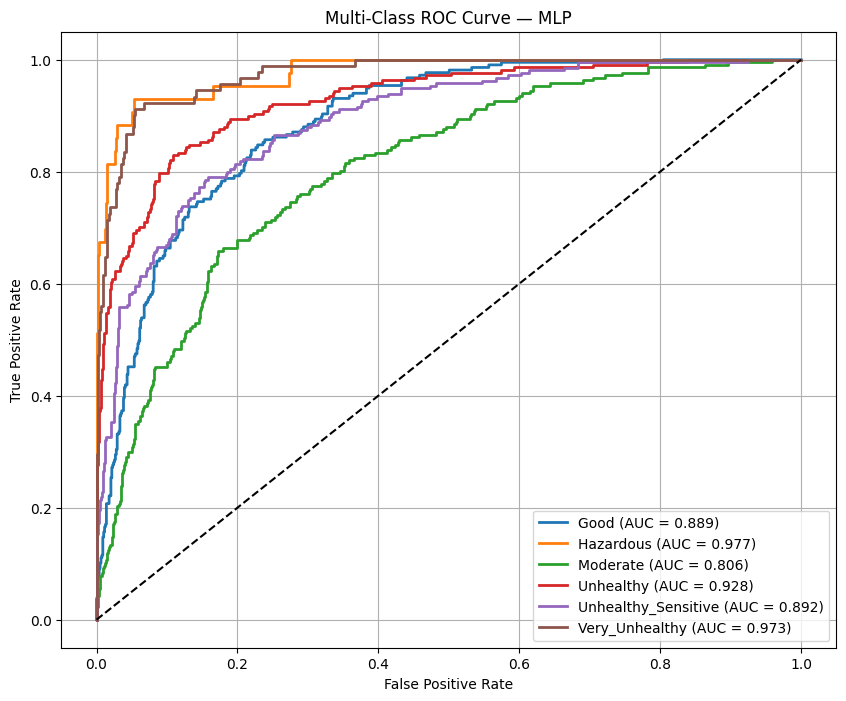


ROC Curve for SVM


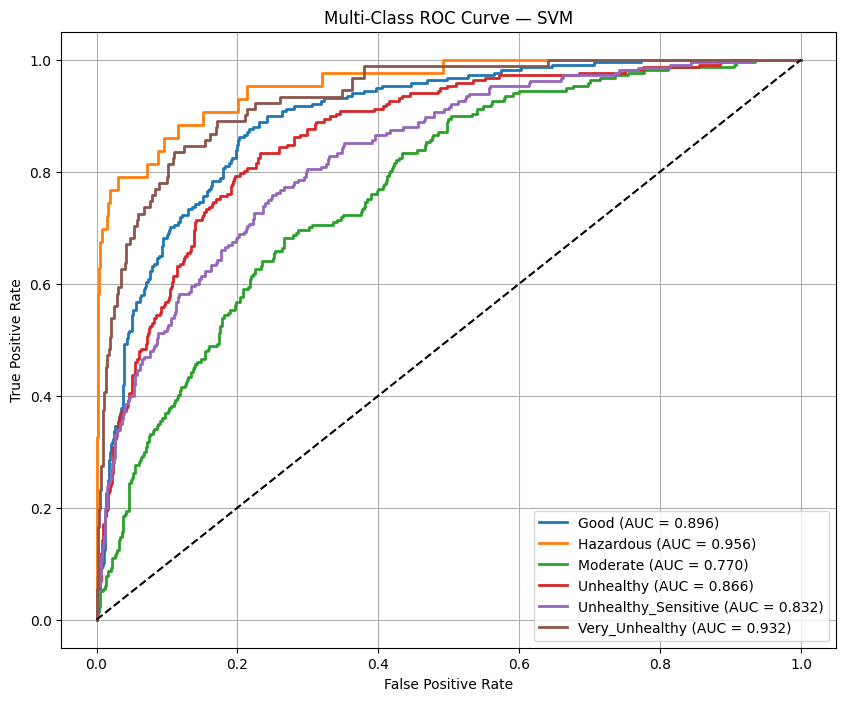


ROC Curve for DecisionTree


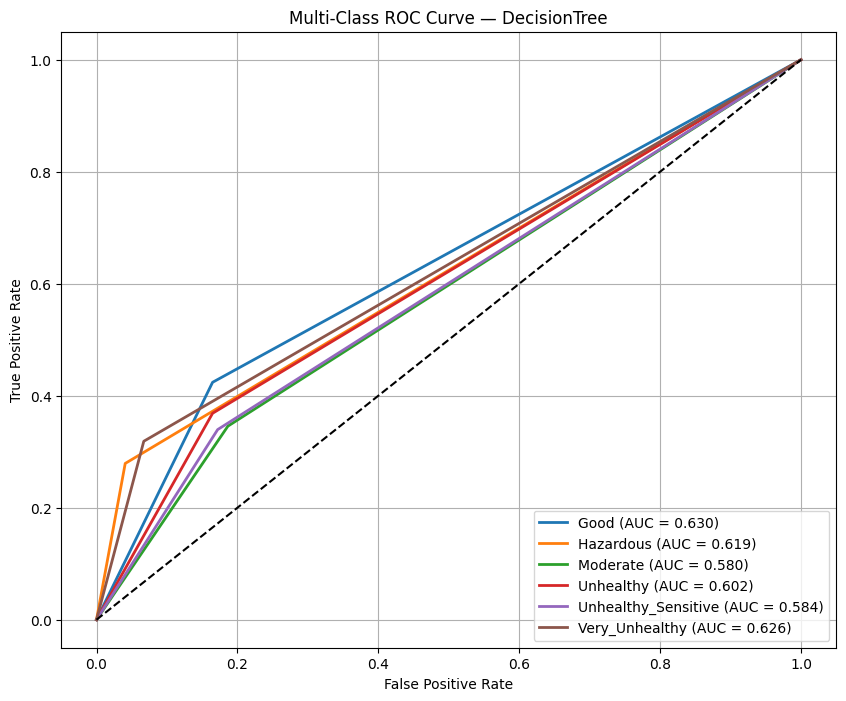


ROC Curve for RandomForest


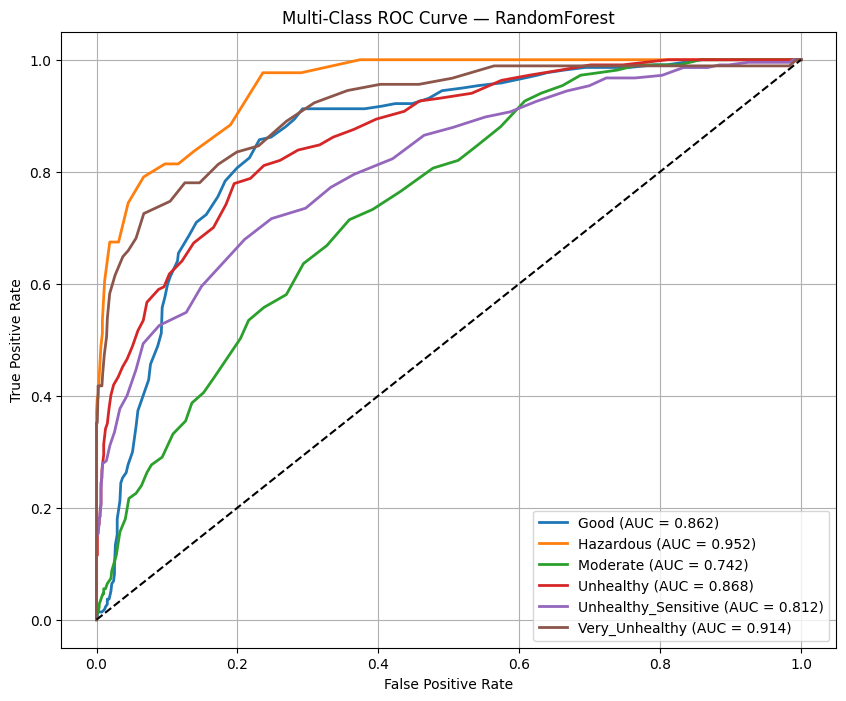

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

classifiers = {
    "MLP": mlp,
    "SVM": svm,
    "DecisionTree": dt,
    "RandomForest": rf
}

for name, model in classifiers.items():

    print(f"\n======================")
    print(f"ROC Curve for {name}")
    print(f"======================")

    
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(val_X)
    else:
        
        probs = softmax(model.decision_function(val_X), axis=1)

    y_bin = label_binarize(val_y, classes=list(range(NUM_CLASSES)))

    
    plt.figure(figsize=(10, 8))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{idx_to_class[i]} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multi-Class ROC Curve — {name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


This block evaluates each trained classifier (MLP, SVM, Decision Tree, Random Forest) on the validation set by generating predictions, computing overall accuracy, and calculating per-class accuracy by filtering validation samples class-wise. It then prints a detailed classification_report (precision/recall/F1 per class) and visualizes the confusion matrix for each model using a Seaborn heatmap with class names on both axes.


MLP — Evaluation
Overall Accuracy (MLP): 65.90%

Per-Class Accuracy:
                     Accuracy (%)
Good                        66.82
Hazardous                   67.44
Moderate                    56.22
Unhealthy                   76.04
Unhealthy_Sensitive         61.40
Very_Unhealthy              72.53

Classification Report:
                     precision    recall  f1-score   support

               Good      0.639     0.668     0.653       217
          Hazardous      0.784     0.674     0.725        43
           Moderate      0.508     0.562     0.534       217
          Unhealthy      0.721     0.760     0.740       217
Unhealthy_Sensitive      0.725     0.614     0.665       215
     Very_Unhealthy      0.776     0.725     0.750        91

           accuracy                          0.659      1000
          macro avg      0.692     0.667     0.678      1000
       weighted avg      0.666     0.659     0.661      1000



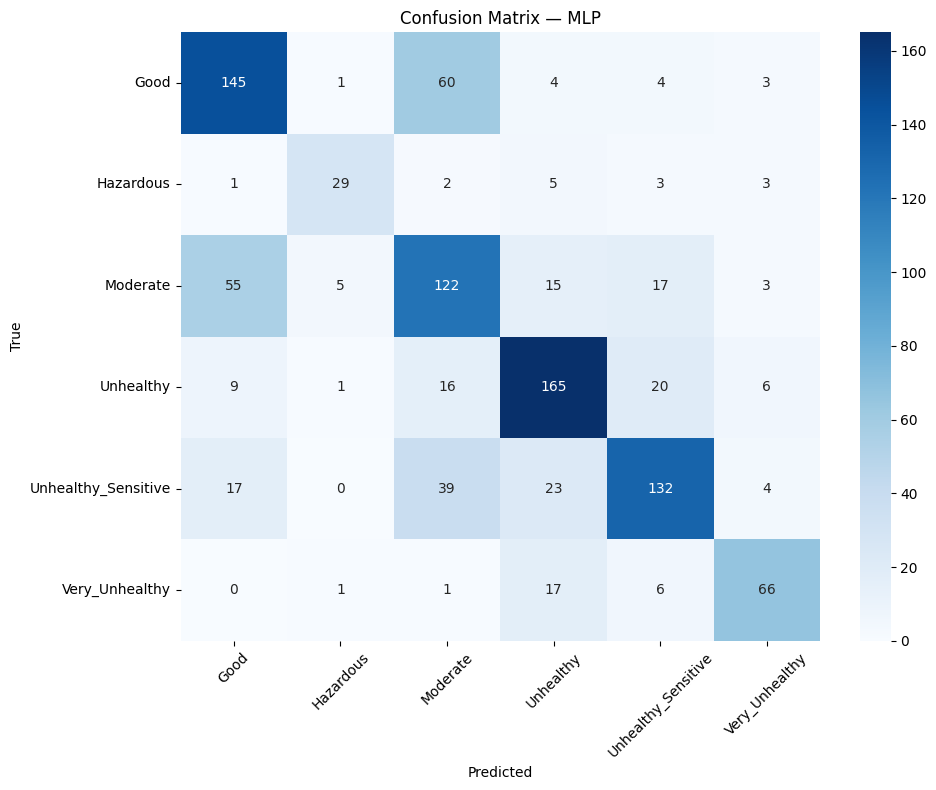


SVM — Evaluation
Overall Accuracy (SVM): 58.10%

Per-Class Accuracy:
                     Accuracy (%)
Good                        64.52
Hazardous                   72.09
Moderate                    54.84
Unhealthy                   59.45
Unhealthy_Sensitive         53.95
Very_Unhealthy              50.55

Classification Report:
                     precision    recall  f1-score   support

               Good      0.619     0.645     0.632       217
          Hazardous      0.689     0.721     0.705        43
           Moderate      0.461     0.548     0.501       217
          Unhealthy      0.635     0.594     0.614       217
Unhealthy_Sensitive      0.574     0.540     0.556       215
     Very_Unhealthy      0.697     0.505     0.586        91

           accuracy                          0.581      1000
          macro avg      0.613     0.592     0.599      1000
       weighted avg      0.589     0.581     0.582      1000



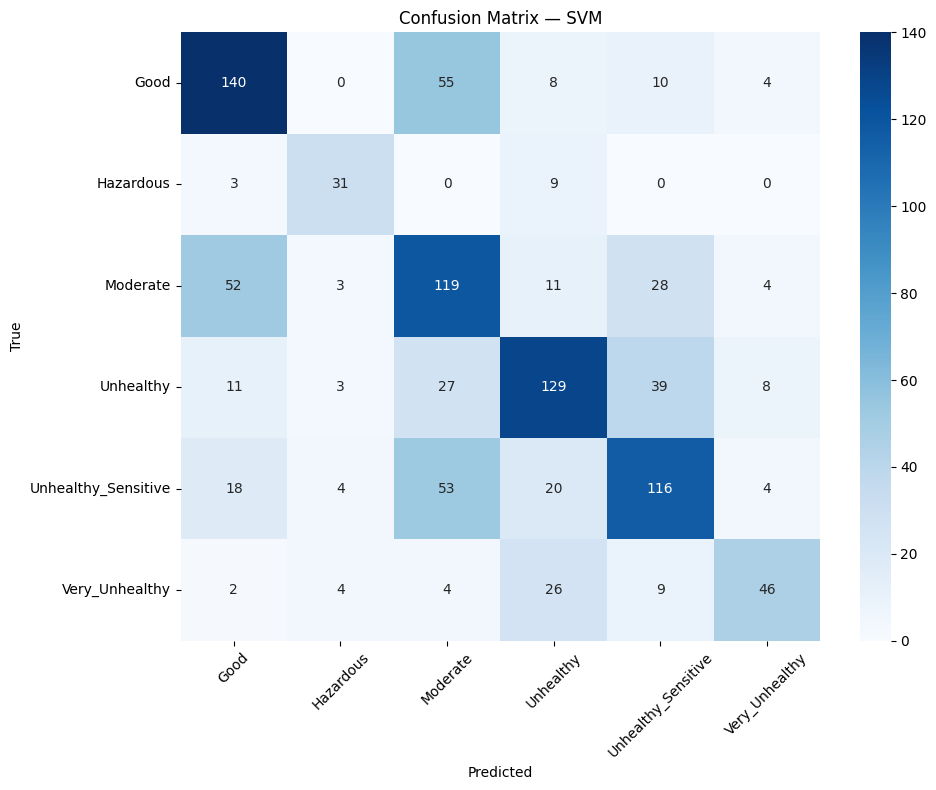


DecisionTree — Evaluation
Overall Accuracy (DecisionTree): 36.10%

Per-Class Accuracy:
                     Accuracy (%)
Good                        42.40
Hazardous                   27.91
Moderate                    34.56
Unhealthy                   36.87
Unhealthy_Sensitive         33.95
Very_Unhealthy              31.87

Classification Report:
                     precision    recall  f1-score   support

               Good      0.416     0.424     0.420       217
          Hazardous      0.235     0.279     0.255        43
           Moderate      0.339     0.346     0.342       217
          Unhealthy      0.383     0.369     0.376       217
Unhealthy_Sensitive      0.351     0.340     0.345       215
     Very_Unhealthy      0.322     0.319     0.320        91

           accuracy                          0.361      1000
          macro avg      0.341     0.346     0.343      1000
       weighted avg      0.362     0.361     0.361      1000



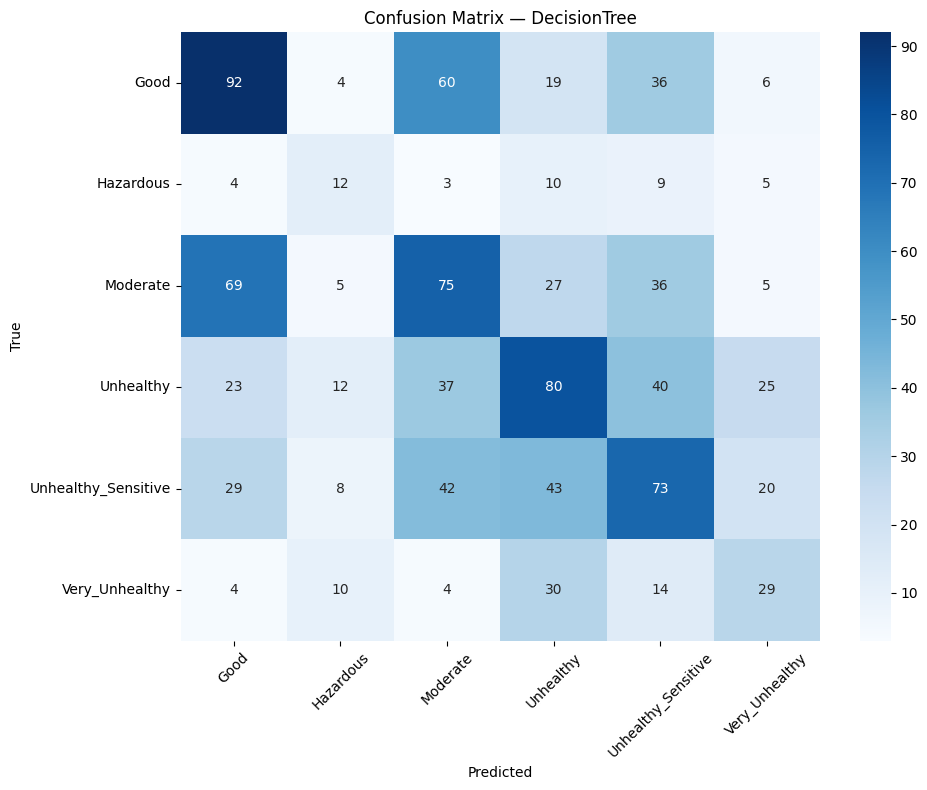


RandomForest — Evaluation
Overall Accuracy (RandomForest): 52.50%

Per-Class Accuracy:
                     Accuracy (%)
Good                        69.59
Hazardous                   27.91
Moderate                    35.02
Unhealthy                   62.67
Unhealthy_Sensitive         54.88
Very_Unhealthy              35.16

Classification Report:
                     precision    recall  f1-score   support

               Good      0.497     0.696     0.580       217
          Hazardous      1.000     0.279     0.436        43
           Moderate      0.390     0.350     0.369       217
          Unhealthy      0.636     0.627     0.631       217
Unhealthy_Sensitive      0.486     0.549     0.515       215
     Very_Unhealthy      1.000     0.352     0.520        91

           accuracy                          0.525      1000
          macro avg      0.668     0.475     0.509      1000
       weighted avg      0.569     0.525     0.520      1000



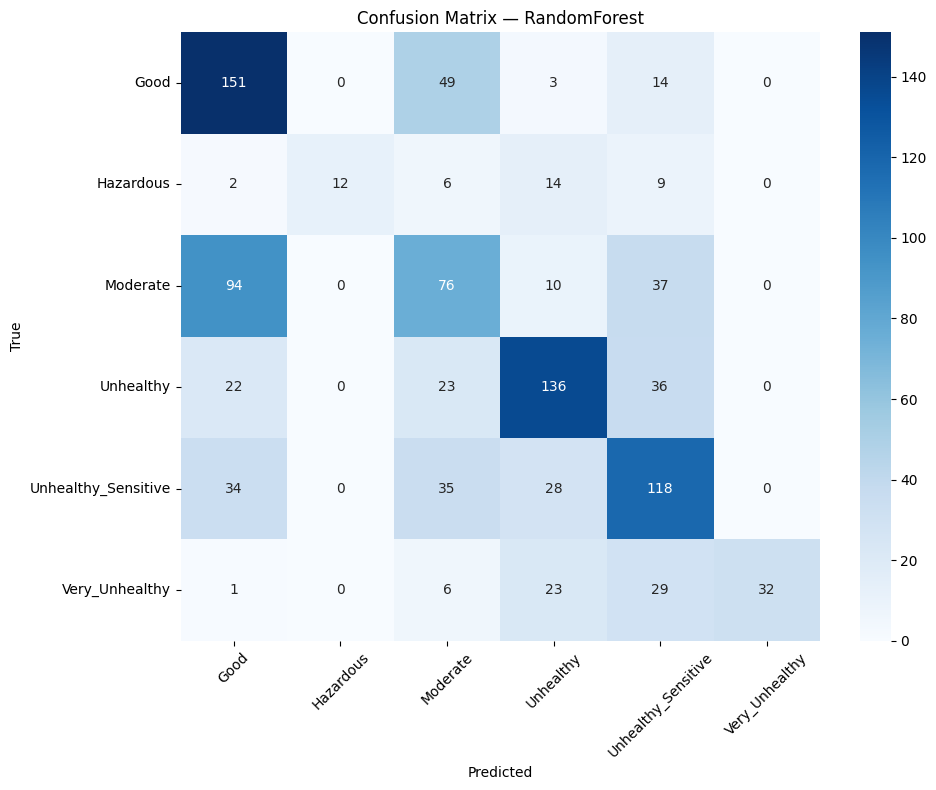

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

classifiers = {
    "MLP": mlp,
    "SVM": svm,
    "DecisionTree": dt,
    "RandomForest": rf
}

for name, model in classifiers.items():

    print(f"\n======================")
    print(f"{name} — Evaluation")
    print(f"======================")

    preds = model.predict(val_X)

    acc = accuracy_score(val_y, preds)
    print(f"Overall Accuracy ({name}): {acc * 100:.2f}%")

    per_class_acc = {}
    for c in range(NUM_CLASSES):
        idx = np.where(val_y == c)[0]
        per_class_acc[idx_to_class[c]] = accuracy_score(val_y[idx], preds[idx]) * 100

    df_acc = pd.DataFrame.from_dict(per_class_acc, orient='index', columns=['Accuracy (%)'])
    print("\nPer-Class Accuracy:")
    print(df_acc.to_string(float_format="%.2f"))


    print("\nClassification Report:")
    print(classification_report(val_y, preds, target_names=[idx_to_class[i] for i in range(NUM_CLASSES)], digits=3))

    cm = confusion_matrix(val_y, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[idx_to_class[i] for i in range(NUM_CLASSES)],
                yticklabels=[idx_to_class[i] for i in range(NUM_CLASSES)])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix — {name}")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


This block benchmarks the classical classifiers by re-fitting each one to measure training time, then computing and printing both training and validation accuracy for comparison. It stores timing and accuracy results in dictionaries, keeps the MLP’s training loss curve (since only MLP provides loss_curve_), and finally visualizes (1) training time as a bar chart, (2) validation accuracy as a bar chart, and (3) the MLP loss curve over iterations to show its optimization behavior.


 TRAINING & EVALUATION (ALL)


------------------------------
⏳ Evaluating: MLP
------------------------------
Iteration 1, loss = 1.44568690
Iteration 2, loss = 1.08409004
Iteration 3, loss = 0.88855249
Iteration 4, loss = 0.74443300
Iteration 5, loss = 0.63190839
Iteration 6, loss = 0.53125642
Iteration 7, loss = 0.45125496
Iteration 8, loss = 0.37619241
Iteration 9, loss = 0.31394235
Iteration 10, loss = 0.25399324
Iteration 11, loss = 0.20795175
Iteration 12, loss = 0.16645191
Iteration 13, loss = 0.13061517
Iteration 14, loss = 0.10280494
Iteration 15, loss = 0.08223437
Iteration 16, loss = 0.06454874
Iteration 17, loss = 0.05204195
Iteration 18, loss = 0.04158889
Iteration 19, loss = 0.03368254
Iteration 20, loss = 0.02768588
Iteration 21, loss = 0.02299441
Iteration 22, loss = 0.01947414
Iteration 23, loss = 0.01665612
Iteration 24, loss = 0.01413250
Iteration 25, loss = 0.01235588
Iteration 26, loss = 0.01082464
Iteration 27, loss = 0.00956394
Iteration 28, loss = 0.00852957
I

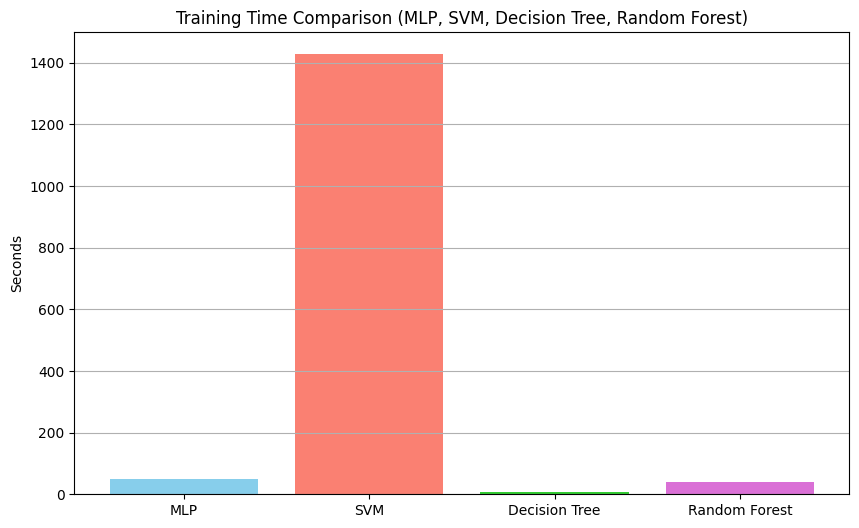

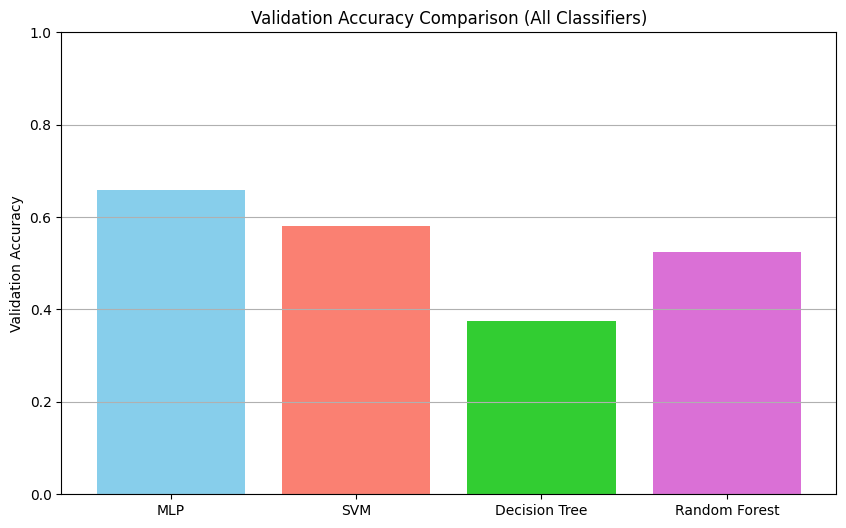

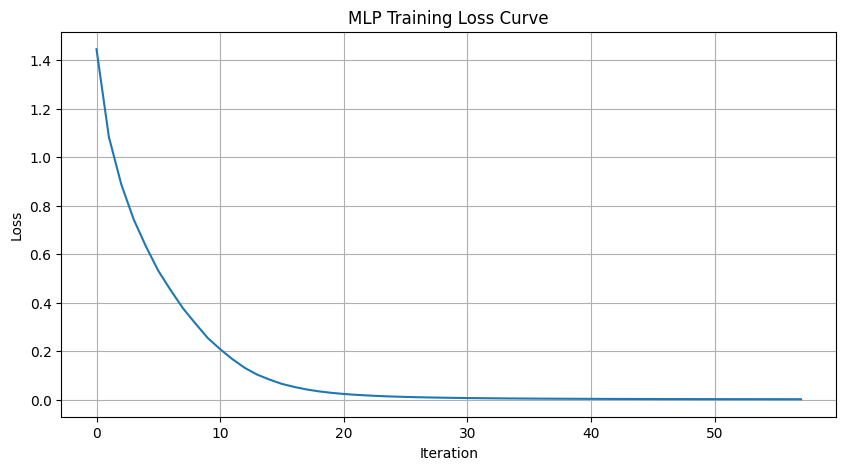

In [ ]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

classifiers = {
    "MLP": mlp,
    "SVM": svm,
    "Decision Tree": dt,
    "Random Forest": rf
}

train_times = {}
train_accuracies = {}
val_accuracies = {}
loss_curves = {}

print("\n==============================")
print(" TRAINING & EVALUATION (ALL)")
print("==============================\n")

for name, model in classifiers.items():

    print(f"\n------------------------------")
    print(f"⏳ Evaluating: {name}")
    print(f"------------------------------")

    start = time.time()

    model.fit(train_X, train_y)

    end = time.time()
    train_times[name] = end - start

    train_preds = model.predict(train_X)
    val_preds = model.predict(val_X)

    train_acc = accuracy_score(train_y, train_preds)
    val_acc = accuracy_score(val_y, val_preds)

    train_accuracies[name] = train_acc
    val_accuracies[name] = val_acc

    print(f"Training Time: {train_times[name]:.2f} sec")
    print(f"Train Accuracy: {train_acc*100:.2f}%")
    print(f"Val Accuracy: {val_acc*100:.2f}%")

    if name == "MLP":
        loss_curves[name] = model.loss_curve_
    else:
        loss_curves[name] = None


plt.figure(figsize=(10, 6))
plt.bar(train_times.keys(), train_times.values(), color=['skyblue','salmon','limegreen','orchid'])
plt.ylabel("Seconds")
plt.title("Training Time Comparison (MLP, SVM, Decision Tree, Random Forest)")
plt.grid(axis='y')
plt.show()



plt.figure(figsize=(10, 6))
x = range(len(classifiers))
plt.bar(x, [val_accuracies[c] for c in classifiers], tick_label=list(classifiers.keys()),
        color=['skyblue','salmon','limegreen','orchid'])
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison (All Classifiers)")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()


if loss_curves["MLP"] is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(loss_curves["MLP"])
    plt.title("MLP Training Loss Curve")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()
else:
    print("\n(No loss curve for SVM / Decision Tree / Random Forest)")


This block tests a cosine-distance k-NN classifier on the extracted feature vectors by training separate KNN models with different neighbor counts (k = 1, 5, 20). For each k, it fits on the training features, predicts the validation labels, computes validation accuracy, and prints the result to compare how k affects performance.

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1, 5, 20]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn.fit(train_X, train_y)

    val_preds = knn.predict(val_X)
    acc = accuracy_score(val_y, val_preds)

    print(f"🔹 k = {k}: Validation Accuracy = {acc * 100:.2f}%")


🔹 k = 1: Validation Accuracy = 66.00%
🔹 k = 5: Validation Accuracy = 63.30%
🔹 k = 20: Validation Accuracy = 58.90%


This block measures label efficiency by repeatedly training classifiers on small random subsets of the training features (1%, 5%, 10%, 25%, 50%) and evaluating on the full validation set. For each fraction, it samples a subset with a fixed seed for reproducibility, trains four models (multinomial logistic regression as a linear probe, linear SVM, decision tree, and random forest), stores their validation accuracies, and finally plots accuracy vs. percentage of labeled data to compare how quickly each method improves as more labels are available.

Fraction 1% complete.
Fraction 5% complete.
Fraction 10% complete.
Fraction 25% complete.


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fraction 50% complete.


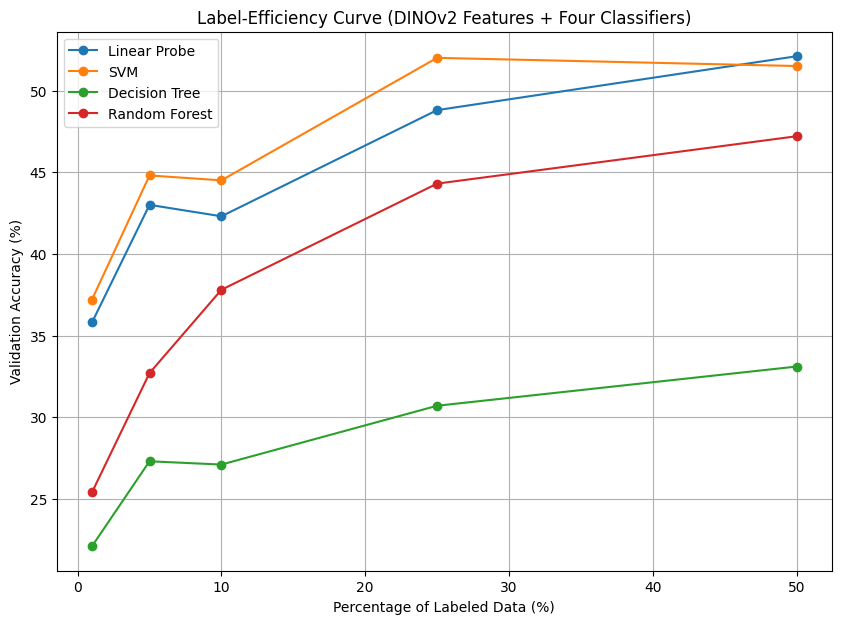

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

fractions = [0.01, 0.05, 0.10, 0.25, 0.50]
n_train = train_X.shape[0]

linear_probe_accuracies = []
svm_accuracies = []
dt_accuracies = []
rf_accuracies = []

for frac in fractions:
    n_samples = max(1, int(n_train * frac))
    np.random.seed(42)
    indices = np.random.choice(n_train, n_samples, replace=False)

    X_subset = train_X[indices]
    y_subset = train_y[indices]

    clf = LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000
    )
    clf.fit(X_subset, y_subset)
    val_preds = clf.predict(val_X)
    linear_probe_accuracies.append(accuracy_score(val_y, val_preds))

    svm = SVC(kernel="linear", probability=True)
    svm.fit(X_subset, y_subset)
    svm_accuracies.append(accuracy_score(val_y, svm.predict(val_X)))

    dt = DecisionTreeClassifier()
    dt.fit(X_subset, y_subset)
    dt_accuracies.append(accuracy_score(val_y, dt.predict(val_X)))

    rf = RandomForestClassifier(n_estimators=200)
    rf.fit(X_subset, y_subset)
    rf_accuracies.append(accuracy_score(val_y, rf.predict(val_X)))

    print(f"Fraction {frac*100:.0f}% complete.")

plt.figure(figsize=(10,7))
plt.plot([f*100 for f in fractions], [x*100 for x in linear_probe_accuracies], marker='o', label="Linear Probe")
plt.plot([f*100 for f in fractions], [x*100 for x in svm_accuracies], marker='o', label="SVM")
plt.plot([f*100 for f in fractions], [x*100 for x in dt_accuracies], marker='o', label="Decision Tree")
plt.plot([f*100 for f in fractions], [x*100 for x in rf_accuracies], marker='o', label="Random Forest")

plt.xlabel("Percentage of Labeled Data (%)")
plt.ylabel("Validation Accuracy (%)")
plt.title("Label-Efficiency Curve (DINOv2 Features + Four Classifiers)")
plt.grid(True)
plt.legend()
plt.show()
